This notebook was created by Donyl Alcantara

# Network Topology of Reddit

### Overview

Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since the 1500s, when an unknown printer took a galley of type and scrambled it to make a type specimen book. It has survived not only five centuries, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised in the 1960s with the release of Letraset sheets containing Lorem Ipsum passages, and more recently with desktop publishing software like Aldus PageMaker including versions of Lorem Ipsum.



## Section 1: Environment Configuration

#### 1.1 Environment Setup

In [87]:
import pandas as pd
import re
import zstandard as zstd
import io
import orjson
from collections import defaultdict
import json
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import csv
import polars as pl
import os
import gdown
import numpy as np
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
from pathlib import Path
import powerlaw
import mapclassify
from scipy.sparse import csr_matrix

#### 1.2 Import `user_subreddit_interactions` from `analytics`

In [71]:
df_all = pl.scan_parquet('analytics/user_subreddit_interactions.parquet').collect()
df_all 

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Shatter_starx""","""pcmasterrace""",0,22,22
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


## Section 2: Data Pre-Processing/Exploratory Data Analysis

According to [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/), due to the existence of significant noise, including the possibility of repeated interactions, specifically because of 'bot users,' we initially do the following: 

- Normalize subreddit names (done in 00)
- Filter self-referential interactions 
- Remove interactions made by top 2% users
- Remove single-interaction subreddit pairs
- Merge interactions between subreddit pairs


#### 2.1 User Activity Aggregation

In [72]:
# total interaction per author 

df_author_interaction = df_all.group_by('author').agg(
    pl.col("interaction_count").sum().alias('interaction_per_user')).sort(
    'interaction_per_user', descending=True) # convert into eager df

# create rank col
df_author_interaction = df_author_interaction.with_columns(pl.arange(
    1, df_author_interaction.height + 1).alias("rank")) # height = number of rows, width = number of cols

df_author_interaction.head(20)

author,interaction_per_user,rank
str,i64,i64
"""donut-bot""",163298,1
"""TipOfTheirTongue""",162697,2
"""VisualMod""",100202,3
"""MinecraftModBot""",89755,4
"""MrPuma86""",65225,5
…,…,…
"""Sky-876""",20904,16
"""bvandepol""",20343,17
"""AskWomen-ModTeam""",20105,18


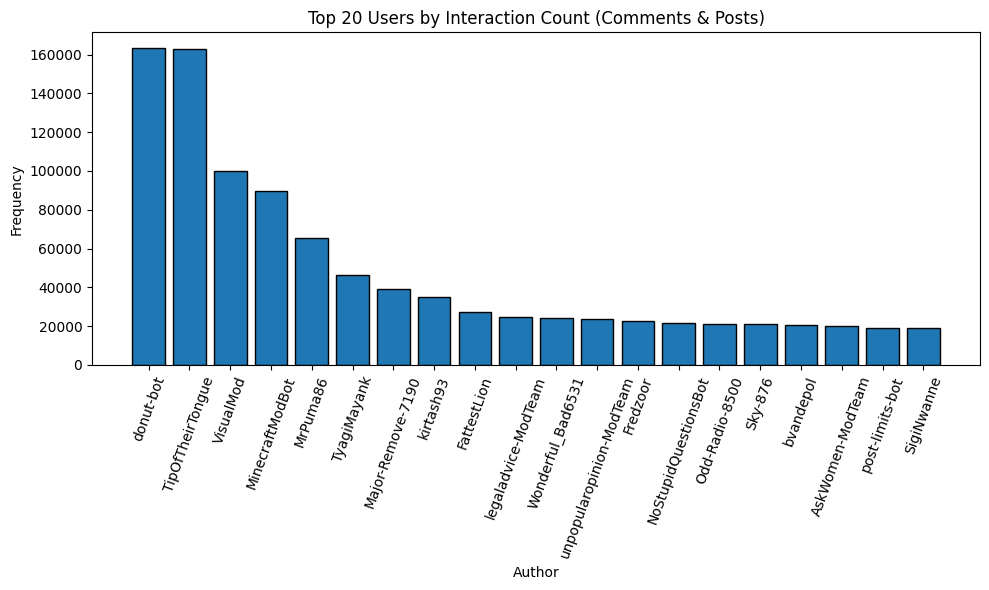

In [76]:
# top 20 

# bar graph
plt.figure(figsize=(10, 6))
plt.bar(df_author_interaction['author'].head(20),
        df_author_interaction['interaction_per_user'].head(20),
        edgecolor='black')
plt.title("Top 20 Users by Interaction Count (Comments & Posts)")
plt.xlabel("Author")
plt.ylabel("Frequency")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

#### 2.2 Rank-Frequency Profiling

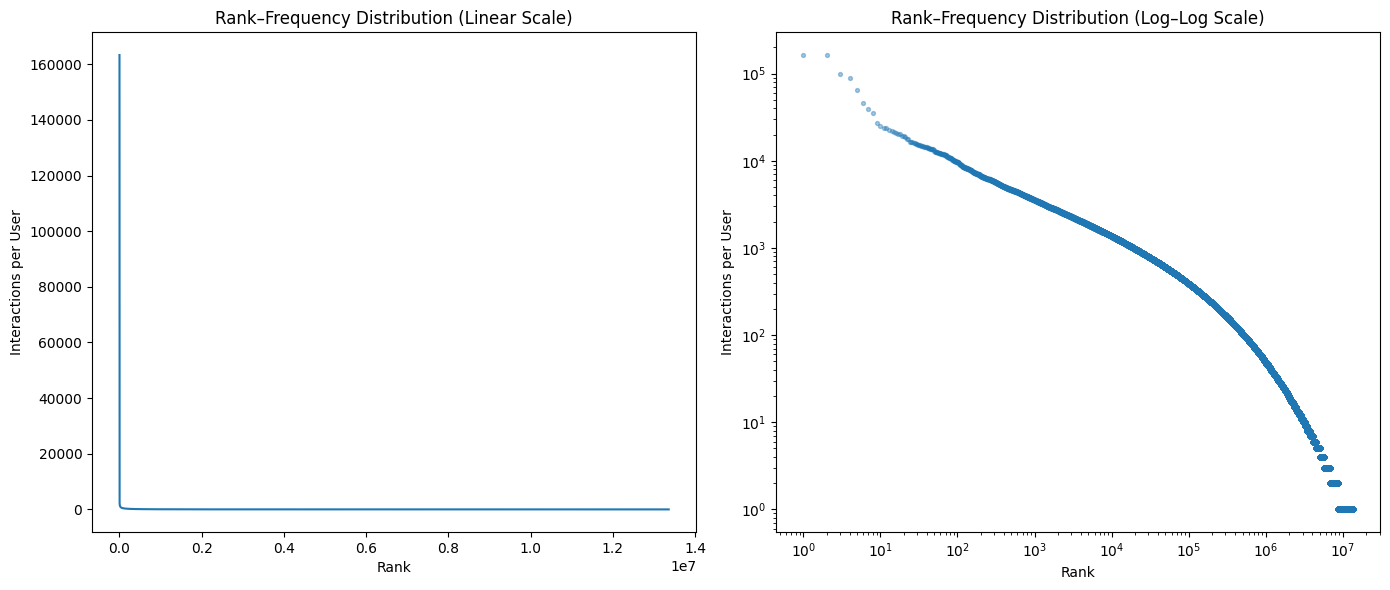

In [77]:
# visualize the long-tail dist with and without scaling
# convert polars series to numpy
x = df_author_interaction['rank'].to_numpy()
y = df_author_interaction['interaction_per_user'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Linear scale
axes[0].plot(x, y)
axes[0].set_title("Rank–Frequency Distribution (Linear Scale)")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Interactions per User")

# Log–Log scale
axes[1].scatter(x, y, alpha=0.4, s=8, color='#1f77b4')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Rank–Frequency Distribution (Log–Log Scale)")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Interactions per User")

plt.tight_layout()
plt.show()

#### 2.3 Outlier/Noise Detection 

#### Log Interquartile Range (IQR)

In [78]:
data = df_author_interaction["interaction_per_user"].to_numpy()
log_data = np.log1p(data)

Q1 = np.percentile(log_data, 25)
Q3 = np.percentile(log_data, 75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = data[log_data > upper_bound]

print(f"Outlier threshold: {np.expm1(upper_bound):.0f}")

Outlier threshold: 111


#### Contribution Share

The distribution of user activity exhibits a pronounced long-tail. We observe a high concentration of activity among a small subset of users: the top 2% of contributors account for approximately 47% of all interactions. This extreme inequality suggests that a small number of highly active users disproportionately shape the interaction network. To mitigate this bias and reduce potential noise from automated or hyperactive accounts, we remove users whose interaction counts fall within the top 2% of the distribution.

In [8]:
# sort descending
df_cs = df_author_interaction.sort("interaction_per_user", descending=True)
total_interactions = df_cs["interaction_per_user"].sum()

# iterate over top 1 to 20%
for pct in range(1, 21):
    n_top = int(df_cs.height * (pct/100))
    top_users = df_cs.head(n_top)
    share = top_users["interaction_per_user"].sum() / total_interactions
    print(f"Top {pct}% users: {n_top}, Contribution share: {share:.2f}")

Top 1% users: 133614, Contribution share: 0.35
Top 2% users: 267228, Contribution share: 0.47
Top 3% users: 400842, Contribution share: 0.55
Top 4% users: 534456, Contribution share: 0.60
Top 5% users: 668070, Contribution share: 0.65
Top 6% users: 801684, Contribution share: 0.68
Top 7% users: 935298, Contribution share: 0.71
Top 8% users: 1068912, Contribution share: 0.74
Top 9% users: 1202526, Contribution share: 0.76
Top 10% users: 1336140, Contribution share: 0.77
Top 11% users: 1469754, Contribution share: 0.79
Top 12% users: 1603368, Contribution share: 0.81
Top 13% users: 1736983, Contribution share: 0.82
Top 14% users: 1870597, Contribution share: 0.83
Top 15% users: 2004211, Contribution share: 0.84
Top 16% users: 2137825, Contribution share: 0.85
Top 17% users: 2271439, Contribution share: 0.86
Top 18% users: 2405053, Contribution share: 0.86
Top 19% users: 2538667, Contribution share: 0.87
Top 20% users: 2672281, Contribution share: 0.88


#### Lorenz Curve and Gini Coefficient

The Gini coefficient of user interactions is 0.83, indicating extreme inequality. The top 2% of users generate 47% of all interactions, confirming that a small subset of highly active users dominates the network. To reduce the influence of these extreme contributors, we remove users within the top 2% of the distribution.

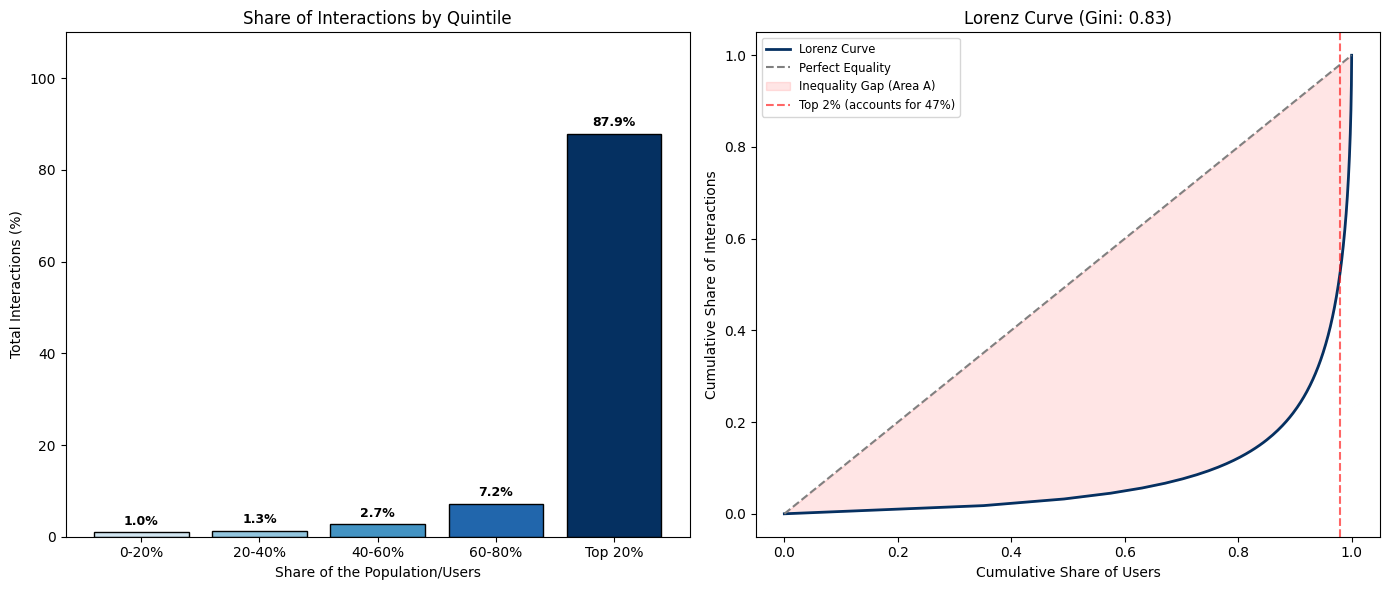

In [79]:
y_sorted = np.sort(df_author_interaction["interaction_per_user"].to_numpy())
total_val = y_sorted.sum()
n_users = len(y_sorted)

# lorenz data
cum_users = np.arange(1, n_users + 1) / n_users
cum_activity = np.cumsum(y_sorted) / total_val
gini = 1 - 2 * np.sum((cum_activity[1:] + cum_activity[:-1]) * np.diff(cum_users) / 2)

# quintile data
groups = np.array_split(y_sorted, 5)
shares = [(g.sum() / total_val) * 100 for g in groups]
quintile_labels = ['0-20%', '20-40%', '40-60%', '60-80%', 'Top 20%']
colors = ['#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061']

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Quintile Bar Chart
bars = ax1.bar(quintile_labels, shares, color=colors, edgecolor='black')
ax1.set_title('Share of Interactions by Quintile')
ax1.set_ylabel('Total Interactions (%)')
ax1.set_xlabel('Share of the Population/Users')
ax1.set_ylim(0, 110)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Lorenz Curve
ax2.plot(cum_users, cum_activity, label='Lorenz Curve', color='#053061', linewidth=2)
ax2.plot([0,1], [0,1], linestyle='--', color='grey', label='Perfect Equality')
ax2.fill_between(cum_users, cum_activity, cum_users, color='red', alpha=0.1, label='Inequality Gap (Area A)')

# threshold 
ax2.axvline(cum_users[int(len(y_sorted) * 0.98)], linestyle='--', color='r', alpha=0.6, label=f'Top 2% (accounts for {(1-cum_activity[int(len(y_sorted) * 0.98)])*100:.0f}%)')
ax2.set_title(f'Lorenz Curve (Gini: {gini:.2f})')
ax2.set_xlabel('Cumulative Share of Users')
ax2.set_ylabel('Cumulative Share of Interactions')
ax2.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

#### 98th Percentile vs. Power-law xmin

Calculating best minimal value for power law fit


Fitting xmin: 100%|█████████████████████████| 4101/4101 [06:13<00:00, 10.98it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


Top 2% threshold: 185.00
Power-law xmin: 622.00


/var/folders/_g/nz39y46d1l93yjn3vj6_jd100000gn/T/ipykernel_13585/1656712637.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


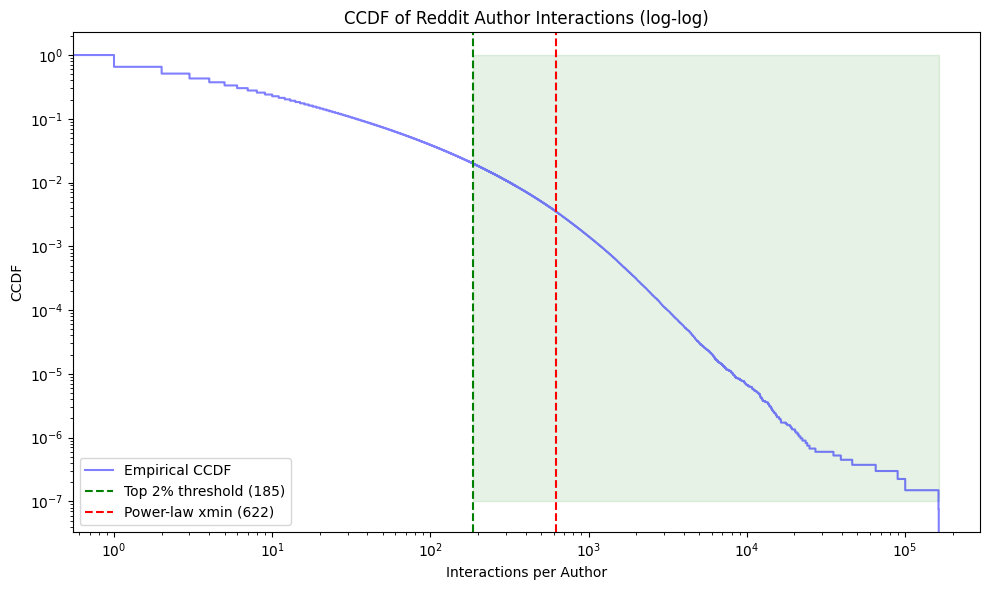

In [80]:
# Data
data = df_author_interaction["interaction_per_user"].to_numpy()

# Compute thresholds
# 98th percentile
threshold_2pct = np.percentile(data, 98)

# Power law params
fit = powerlaw.Fit(data) 
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Top 2% threshold: {threshold_2pct:.2f}")
print(f"Power-law xmin: {xmin:.2f}")

# Compute ECDF and CCDF
ecdf = ECDF(data)
ccdf = 1 - ecdf.y  # CCDF = 1 - CDF

# plot CCDF
plt.figure(figsize=(10,6))
plt.step(ecdf.x, ccdf, where='post', color='blue', alpha=0.5, label='Empirical CCDF')
plt.xscale('log')  # log-log scale
plt.yscale('log')

# threshold lines
plt.axvline(threshold_2pct, color='green', linestyle='--',  
            label=f'Top 2% threshold ({threshold_2pct:.0f})')
plt.axvline(xmin, color='red', linestyle='--',
            label=f'Power-law xmin ({xmin:.0f})')

# shade the top 2%
plt.fill_betweenx(y=[1e-7, 1], x1=threshold_2pct, x2=ecdf.x.max(),
                  color='green', alpha=0.1)

# labels
plt.xlabel("Interactions per Author")
plt.ylabel("CCDF")
plt.title("CCDF of Reddit Author Interactions (log-log)")
# plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Compare Power Law vs. Log-normal
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Loglikelihood ratio (R): {R:.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    if R > 0:
        print("Conclusion: Reject H0. Power Law is a significantly better fit.")
    else:
        print("Conclusion: Reject H0. Log-normal is a significantly better fit.")
else:
    print("Conclusion: Fail to reject H0. Neither distribution is significantly better.")

Loglikelihood ratio (R): -198.21
p-value: 0.0000
Conclusion: Reject H0. Log-normal is a significantly better fit.


Log-normal parameters: mu=3.15, sigma=1.45


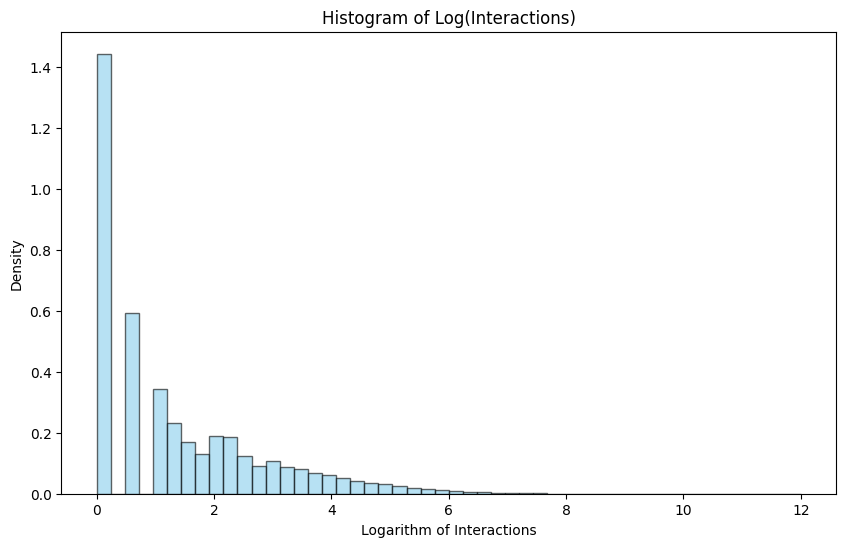

In [15]:
# Extract parameters from the fit
mu = fit.lognormal.mu
sigma = fit.lognormal.sigma

print(f"Log-normal parameters: mu={mu:.2f}, sigma={sigma:.2f}")

# Verification: Plot the histogram of the LOG of the data
log_data = np.log(data[data > 0])
plt.figure(figsize=(10, 6))
plt.hist(log_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title('Histogram of Log(Interactions)')
plt.xlabel('Logarithm of Interactions')
plt.ylabel('Density')
plt.show()

## Section 3: Data Filtration

#### 3.1 Detecting Hyperactive Users (bots or anamalous values)

In [16]:
# get the top 2% df to detect bots and extreme users

threshold_filter = df_author_interaction.select(pl.col('interaction_per_user').quantile(0.98)).item()

df_top_users = df_author_interaction.filter(
    pl.col('interaction_per_user') > threshold_filter).select('author')

display(df_top_users)
print(f'98th Percentile: {threshold_filter}')

author
str
"""donut-bot"""
"""TipOfTheirTongue"""
"""VisualMod"""
"""MinecraftModBot"""
"""MrPuma86"""
…
"""transmogisadumbitch"""
"""HopDropNRoll"""
"""Broadway_Nerdd"""


98th Percentile: 185.0


In [17]:
# sanity check 
top_users_count = df_top_users.height
total_users = df_author_interaction.height
pct = top_users_count / total_users
print(f'{pct:.4f}')

0.0200


In [18]:
# remove top 2%

auti_wo_top = df_author_interaction.join(
    df_top_users,
    on='author',
    how='anti').sort('rank', descending=False)

auti_wo_top

author,interaction_per_user,rank
str,i64,i64
"""Paladin_G""",185,266712
"""No-Fly-8627""",185,266713
"""pissedoffjesus""",185,266714
"""ms-fanto""",185,266715
"""Easy_Rough_4529""",185,266716
…,…,…
"""BuddyJustBuddy""",1,13361404
"""fishstickburner""",1,13361405
"""iMerlin23""",1,13361406


In [33]:
# display reconciled without hyperactive users

df_all_wo_top = df_all.join(
    auti_wo_top.select("author"),
    on="author",
    how="inner"
)

display(df_all_wo_top)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
"""One-Personality3513""","""houseofthedragon""",2,1,3
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


#### 3.2 Detecting Inactive Users

#### Frequency Distribution Table

In [20]:
# number of users for each interaction_per_user (least active to most active)

interaction_per_user_count = (
    auti_wo_top.group_by("interaction_per_user")
    .len()
    .rename({"len": "user_count"})
    .sort("interaction_per_user")
)

interaction_per_user_count = interaction_per_user_count.with_columns((
    (pl.col('user_count') / pl.col('user_count').sum()) * 100).alias('pct (%)'))

interaction_per_user_count.head(10)

interaction_per_user,user_count,pct (%)
i64,u32,f64
1,4627336,35.337481
2,1896163,14.480389
3,1099410,8.395841
4,739755,5.649272
5,539538,4.120279
6,414583,3.166037
7,331496,2.531529
8,271888,2.076321
9,228556,1.745409


#### Head–Tail Breaks for Identifying Inactive Users

To identify inactive Reddit users, the **Head–Tail Breaks (HTB)** algorithm [(Jiang et al., 2013)](https://arxiv.org/abs/1102.1561) was applied to the distribution of total user interactions (`interaction_per_user`). HTB is designed for **heavy-tailed distributions**, where many observations are small and a small minority are large, a pattern pervasive in online participation data.

The method partitions the distribution around the **mean value** into:

- **Head:** values greater than the mean  
- **Tail:** values less than or equal to the mean  

The weighted mean is computed as:

$$
\mu = \frac{\sum (x_i f_i)}{\sum f_i}
$$

where $x_i$ is the number of interactions and $f_i$ is the number of users with that interaction count.

In our case, only the **first HTB iteration** was used to identify the initial separation between low-activity and more active users. Users with interaction counts **below the first mean threshold** were classified as inactive and removed.

Using HTB renders a **data-driven threshold** for filtering minimally active or “drive-by” users, reducing noise and sparsity before constructing the **user–subreddit incidence matrix**.

In [68]:
# head-tail breaks algorithm 

def find_head_tail_break(data):
    current_data = data  # interaction_per_user = value (X)
    iteration = 1    # user_count = frequency (Y)
    
    while True:
        # get weighted mean: (value * frequency) / total frequency
        total_val = (current_data["interaction_per_user"] * current_data["user_count"]).sum()
        total_freq = current_data["user_count"].sum()
        mu = total_val / total_freq
        
        # head = those strictly above the mean
        head = current_data.filter(pl.col("interaction_per_user") > mu)
        
        # calculate percentage of users remaining in head
        head_percentage = head["user_count"].sum() / total_freq
        
        print(f"Iteration {iteration}: Mean = {mu:.2f}, Head % = {head_percentage:.2%}")
        
        # If the head is no longer a small minority (<40%), 
        # or we run out of data, the current mean is our natural threshold.
        if head_percentage > 0.40 or head.height == 0:
            final_threshold = round(mu)
            print(f"\nRESULT")
            print(f"Natural Mathematical Threshold: {final_threshold}")
            return final_threshold
            
        current_data = head
        iteration += 1

# Execute
final_threshold = find_head_tail_break(interaction_per_user_count)

Iteration 1: Mean = 10.78, Head % = 21.00%
Iteration 2: Mean = 41.01, Head % = 31.76%
Iteration 3: Mean = 84.52, Head % = 39.71%
Iteration 4: Mean = 123.40, Head % = 44.17%

RESULT
Natural Mathematical Threshold: 123


In [45]:
# implement head-tail algo using mapclassify lib (sanity check)

interaction_per_user = auti_wo_top["interaction_per_user"].to_numpy()
htb = mapclassify.HeadTailBreaks(interaction_per_user)
count = htb.counts
bins = htb.bins

df_htb = pd.DataFrame({'count (users)': count,
                       'bins (upper bound)': np.round(bins, 2)})

df_htb['class'] = pd.Series(np.arange(1, 13))
df_htb = df_htb[['class', 'count (users)', 'bins (upper bound)']]
df_htb = df_htb.set_index('class')
display(df_htb)

low_activity_thres = df_htb['bins (upper bound)'][1]
print(f'Remove inactive users/first class: < {low_activity_thres:.0f}')
# interpretation: 
# class 1 - Users with interaction_per_user ≤ 10.78 → 10,344,424 users
# class 2 → 10.78 < users ≤ 41.01 → low activity
# class 3 → 41.01 < users ≤ 84.52 → medium activity
# class 4 → 84.52 < users ≤ 123.40 → head (active)

,count (users),bins (upper bound)
class,,
1,10344424,10.78
2,1876882,41.01
3,526589,84.52
4,193626,123.40
5,80868,150.66
6,36556,166.87
7,17659,175.71
8,9373,180.39
9,3599,182.96


Remove inactive users/first class: < 11


In [46]:
# get initially cleaned df without hyperactive ones to filter out inactive ones 
# threshold = > 10 interactions

auti_cleaned = auti_wo_top.filter(pl.col('interaction_per_user') > low_activity_thres)
auti_cleaned

author,interaction_per_user,rank
str,i64,i64
"""Paladin_G""",185,266712
"""No-Fly-8627""",185,266713
"""pissedoffjesus""",185,266714
"""ms-fanto""",185,266715
"""Easy_Rough_4529""",185,266716
…,…,…
"""SomeoneAwesome11""",11,3016980
"""Tiny-Necessary4298""",11,3016981
"""Abhiabhiii""",11,3016982


In [47]:
# display reconciled without hyperactive users

df_all_wo_topnbot = df_all_wo_top.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
).sort('interaction_count', descending=False)

display(df_all_wo_topnbot)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Japparbyn""","""interestingasfuck""",0,1,1
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Chumbief""","""abandonedporn""",0,1,1
"""CozyOdyssey""","""rarepuppers""",0,1,1
"""chappyfu""","""funny""",0,1,1
…,…,…,…,…
"""Regulith""","""destinythegame""",1,184,185
"""Elsweyrwarrior""","""pokemon""",1,184,185
"""dryland305""","""gardening""",2,183,185


### 3.3 Cleaned `user_subreddit_interactions`

In [48]:
# clean df_all (remove top users)

clean_df_all = df_all.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
)

display(clean_df_all)

print("\nSummary:")

print("\nHyperactive Filtration:")
print("Before Removing Hyperactive Users (Top 2%):", df_all.height, "rows")
print("After Removing Hyperactive Users (Top 2%):", df_all_wo_top.height, "rows")
print("No. of Rows Removed (Hyperactive Active Users):", df_all.height - df_all_wo_top.height, "rows")
print(f"Percentage of Rows Removed: {((df_all.height - df_all_wo_top.height)/df_all.height)*100:.2f}%")

print("\nInactive Filtration:")
print("Before Removing Inactive Users (interaction_count < 11):", df_all_wo_top.height, "rows")
print("After Removing  Inactive Users (interaction_count < 11):", df_all_wo_topnbot.height, "rows")
print("No. of Rows Removed (Inactive Users):", df_all_wo_top.height - df_all_wo_topnbot.height, "rows")
print(f"Percentage of Rows Removed: {((df_all_wo_top.height - df_all_wo_topnbot.height)/df_all_wo_top.height)*100:.2f}%")

print('\nTotal:')
print(f"Total Rows Removed: {df_all.height - clean_df_all.height} rows")
print(f"Percentage of Rows Removed: {((df_all.height - clean_df_all.height)/df_all.height)*100:.2f}%")

# 2% of users contributed 14.43% of the total interactions, which is exactly what the long-tail dist shows, hence the need
# to remove them

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BeyondStars_ThenMore""","""facepalm""",0,7,7
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Ok-Protection-1214""","""bollyblindsngossip""",8,25,33
…,…,…,…,…
"""FoxDays""","""starwars""",3,0,3
"""SpruceBingsteen""","""beamazed""",0,1,1
"""spoonyF0rky01""","""news""",0,6,6



Summary:

Hyperactive Filtration:
Before Removing Hyperactive Users (Top 2%): 46724134 rows
After Removing Hyperactive Users (Top 2%): 39981748 rows
No. of Rows Removed (Hyperactive Active Users): 6742386 rows
Percentage of Rows Removed: 14.43%

Inactive Filtration:
Before Removing Inactive Users (interaction_count < 11): 39981748 rows
After Removing  Inactive Users (interaction_count < 11): 22884988 rows
No. of Rows Removed (Inactive Users): 17096760 rows
Percentage of Rows Removed: 42.76%

Total:
Total Rows Removed: 23839146 rows
Percentage of Rows Removed: 51.02%


In [50]:
# save to analytics/parquet
# clean_df_all.write_parquet("analytics/clean_df_all.parquet")

## Section 3: Matrices

#### 3.1 User-Subreddit Matrix (Incidence Matrix)

In [55]:
incidence_matrix = clean_df_all.pivot("subreddit", 
                                      index='author',
                                      values='interaction_count')

incidence_matrix = incidence_matrix.fill_null(0)
incidence_matrix

author,povertyfinance,interestingasfuck,facepalm,getmotivated,bollyblindsngossip,abandonedporn,cryptocurrency,rarepuppers,fortnitebr,mangacollectors,games,nottheonion,sims4,aviation,buildapc,baseball,funny,music,sciencememes,mildlyinfuriating,gameofthrones,pics,aitah,dataisbeautiful,weird,coolguides,collegebasketball,television,gaming,anime,damnthatsinteresting,mapporn,pcmasterrace,law,mildlyinteresting,somethingimade,…,hbo,designporn,nft,mypeopleneedme,disneyplus,healthyfood,metal,meditation,twitch,ofcoursethatsathing,programming,health,animalsbeingjerks,ethtrader,childrenfallingover,beautyguruchatter,100yearsago,highqualitygifs,artporn,powerwashingporn,gamephysics,forbiddensnacks,memeeconomy,reactiongifs,astrophotography,animeart,compsci,deepintoyoutube,artisanvideos,trippinthroughtime,recipes,15minutefood,reallifedoodles,freeebooks,humor,gifrecipes,savedyouaclick
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""Important_Trash_4555""",16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Japparbyn""",11,1,28,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""BeyondStars_ThenMore""",0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""ServingTheMaster""",1,0,1,1,0,0,1,0,0,0,0,0,0,2,5,0,0,0,0,1,0,1,2,0,3,0,0,0,0,0,0,0,2,0,2,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Ok-Protection-1214""",0,0,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Otenus""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""league_legacy""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""MisoKattx""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [69]:
# keep cols that have at least one non-zero value

# compute sums for all columns except 'author'
col_sums = incidence_matrix.drop("author").select([
    pl.sum(col).alias(col) for col in incidence_matrix.drop("author").columns
]).to_dicts()[0]

cols_to_keep = ["author"] + [col for col, total in col_sums.items() if total > 0]
cleaned_incidence_matrix = incidence_matrix.select(cols_to_keep)
cleaned_incidence_matrix

# no col was dropped

author,povertyfinance,interestingasfuck,facepalm,getmotivated,bollyblindsngossip,abandonedporn,cryptocurrency,rarepuppers,fortnitebr,mangacollectors,games,nottheonion,sims4,aviation,buildapc,baseball,funny,music,sciencememes,mildlyinfuriating,gameofthrones,pics,aitah,dataisbeautiful,weird,coolguides,collegebasketball,television,gaming,anime,damnthatsinteresting,mapporn,pcmasterrace,law,mildlyinteresting,somethingimade,…,hbo,designporn,nft,mypeopleneedme,disneyplus,healthyfood,metal,meditation,twitch,ofcoursethatsathing,programming,health,animalsbeingjerks,ethtrader,childrenfallingover,beautyguruchatter,100yearsago,highqualitygifs,artporn,powerwashingporn,gamephysics,forbiddensnacks,memeeconomy,reactiongifs,astrophotography,animeart,compsci,deepintoyoutube,artisanvideos,trippinthroughtime,recipes,15minutefood,reallifedoodles,freeebooks,humor,gifrecipes,savedyouaclick
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""Important_Trash_4555""",16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Japparbyn""",11,1,28,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""BeyondStars_ThenMore""",0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""ServingTheMaster""",1,0,1,1,0,0,1,0,0,0,0,0,0,2,5,0,0,0,0,1,0,1,2,0,3,0,0,0,0,0,0,0,2,0,2,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Ok-Protection-1214""",0,0,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Otenus""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""league_legacy""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""MisoKattx""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [84]:
# drop authors
print(cleaned_incidence_matrix.dtypes)
numeric_matrix = cleaned_incidence_matrix.drop("author")

[String, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int6

In [85]:
# 
B = csr_matrix(numeric_matrix )
B

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 22884988 stored elements and shape (2750273, 500)>

#### 3.2 Compute Subreddit Adjacency Matrix

In [93]:
adjacency_matrix = B.T @ B
# Remove Self-Loops

adjacency_matrix.setdiag(0)

# Remove zeros
adjacency_matrix.eliminate_zeros()
adjacency_matrix

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 248250 stored elements and shape (500, 500)>

In [95]:
# number of edges or subreddit connections
print(adjacency_matrix.nnz)

248250


In [99]:
# Remove single-interaction subreddit pairs - from [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/)
adjacency_matrix.data[adjacency_matrix.data == 1] = 0
adjacency_matrix.eliminate_zeros()

In [98]:
# convert matrix into graph
reddit_network = nx.from_scipy_sparse_array(adjacency_matrix)
reddit_network

In [101]:
# sanity check
print("Number of nodes:", reddit_network.number_of_nodes())
print("Number of edges:", reddit_network.number_of_edges())

Number of nodes: 500
Number of edges: 123849


In [113]:
# assign 

# import previously processed list 
subreddit_list = pd.read_csv('data/subreddits.csv')
subreddit_list = subreddit_list["subreddit"].tolist()

# map to assign names to nodes
mapping = dict(enumerate(subreddit_list))
reddit_network = nx.relabel_nodes(reddit_network, mapping)

In [116]:
# Inspect Edge Weights
weights = [d['weight'] for _,_,d in reddit_network.edges(data=True)]

import numpy as np
print(np.percentile(weights, [50,75,90,95,99]))

[  2345.    10343.    36882.2   78887.6  328078.56]


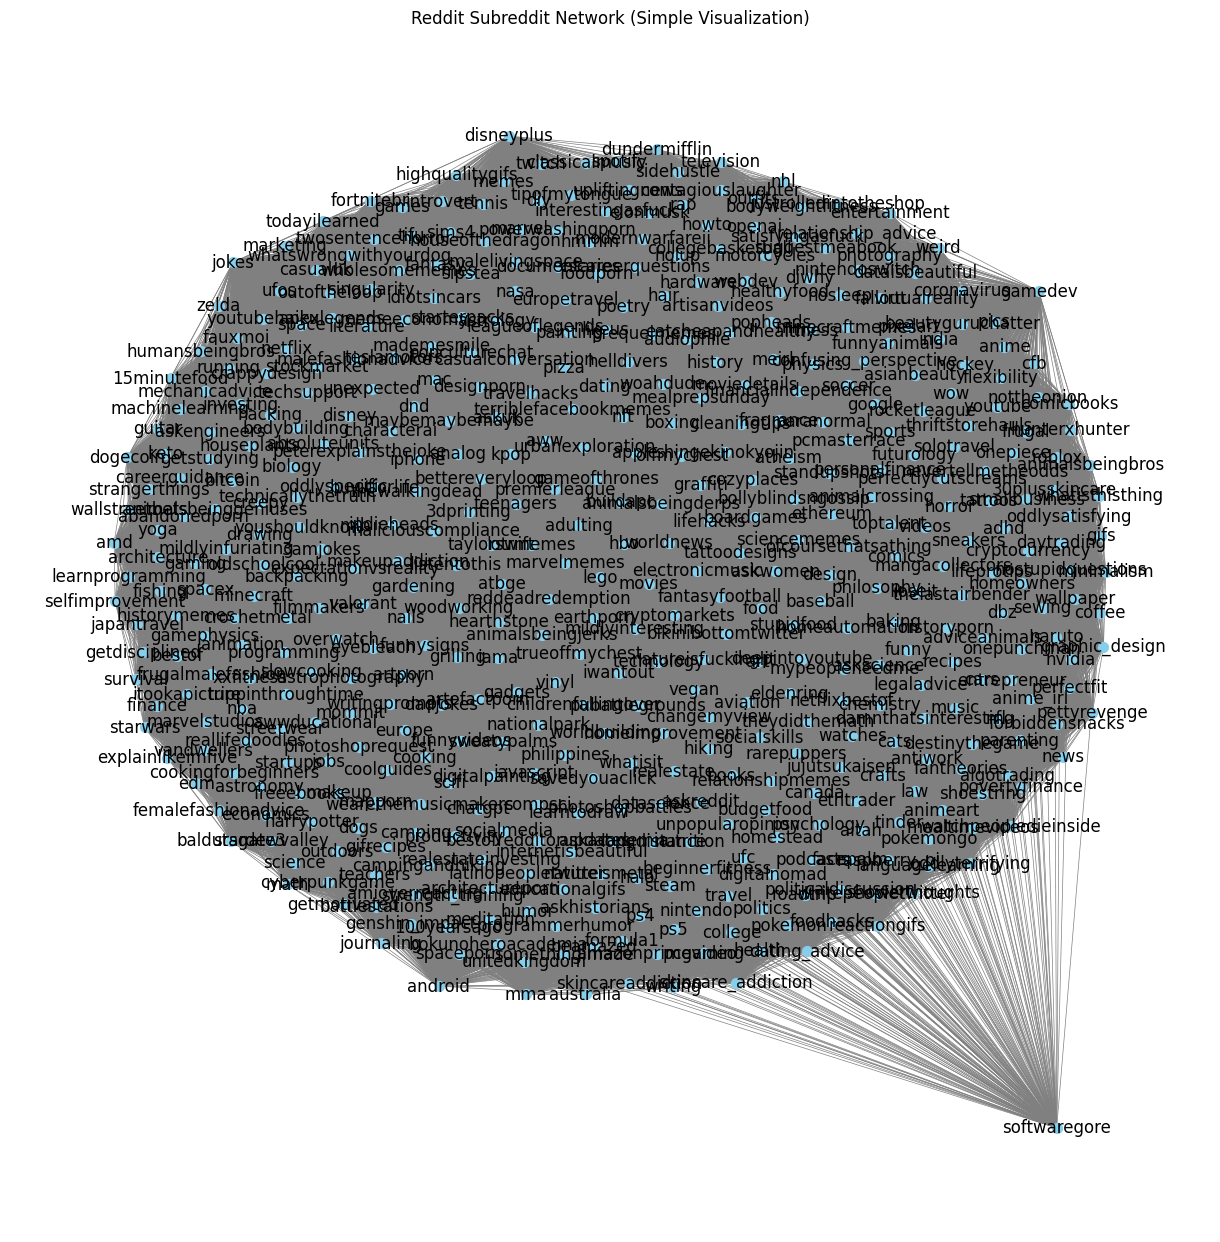

In [139]:
# Simple spring layout (force-directed)
pos = nx.spring_layout(reddit_network, seed=42, k=0.3)

# Draw nodes and edges
plt.figure(figsize=(12, 12))
nx.draw(
    reddit_network,
    pos=pos,
    node_size=50,        # keep small for large networks
    node_color="skyblue",
    edge_color="gray",
    width=0.5,           # thin edges
    with_labels=True   # no labels yet for clarity
)
plt.title("Reddit Subreddit Network (Simple Visualization)")
plt.show()

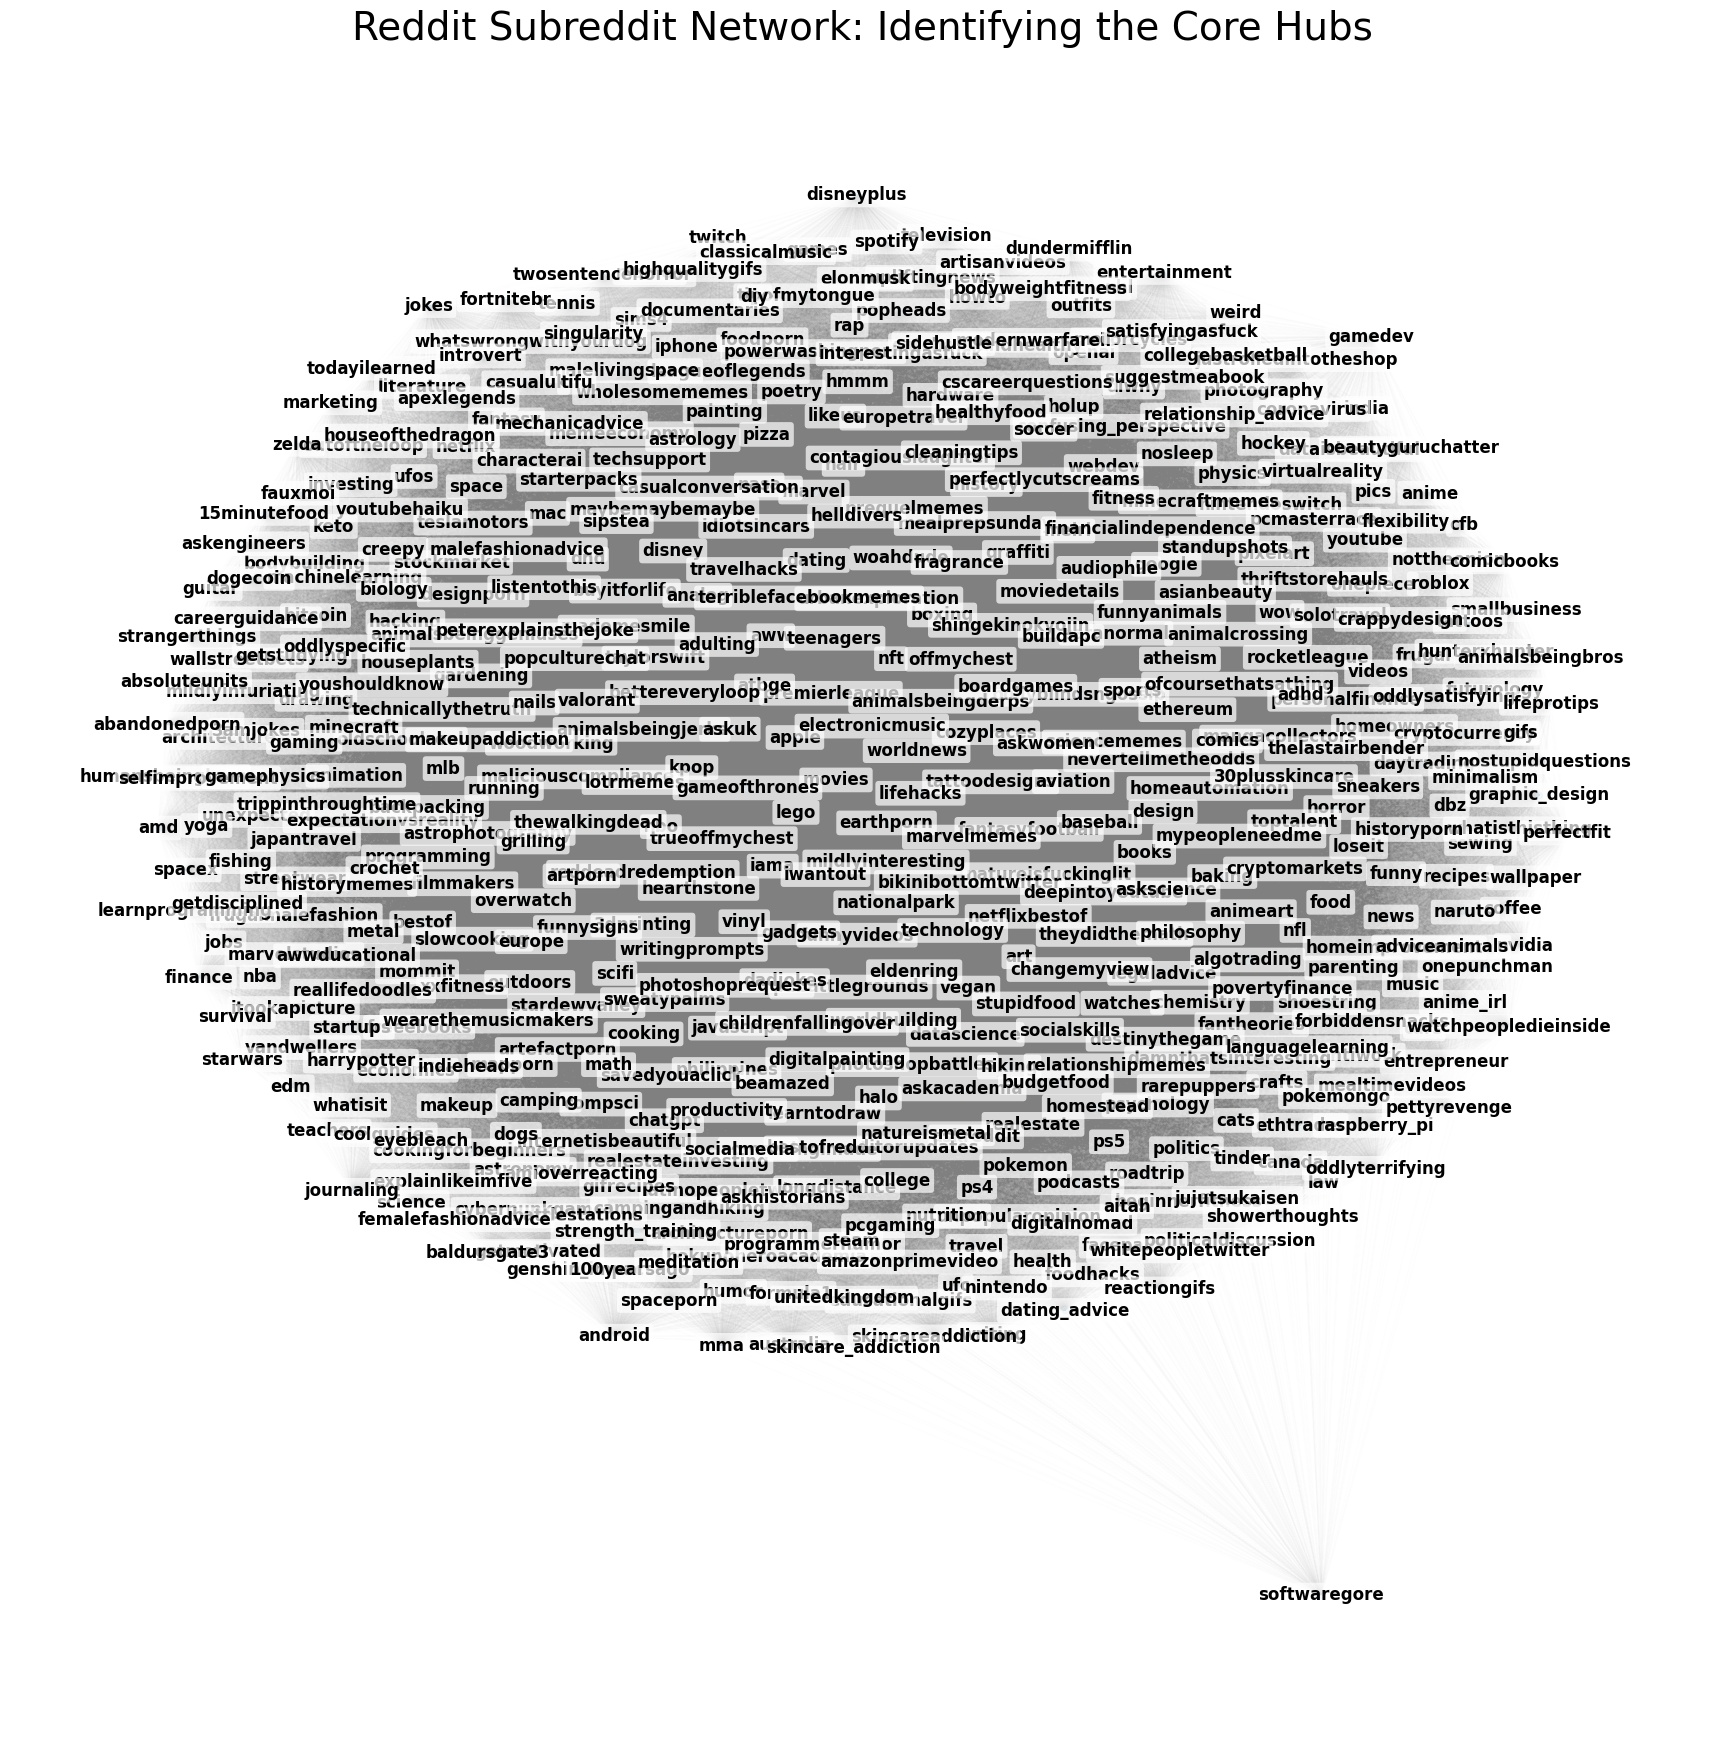

In [144]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Increase k even more to force the "Big Bang" expansion
# k=3.0 is a massive distance, which will force the labels apart
pos = nx.spring_layout(reddit_network, k=3.0, iterations=50, seed=42)

plt.figure(figsize=(22, 22)) # High resolution is key

# 2. Draw Edges as ultra-faint shadows (1% opacity)
# This removes the gray 'fog' you see in your screenshot
nx.draw_networkx_edges(reddit_network, pos, alpha=0.01, edge_color="gray")

# 3. Draw Nodes very small and transparent
# This lets the text be the 'hero' of the image
nx.draw_networkx_nodes(reddit_network, pos, node_size=20, node_color="skyblue", alpha=0.3)

# 4. SMART LABELING: Only the top influencers
# We only label subreddits with many connections (degree > threshold)
degrees = dict(reddit_network.degree())
threshold = 40  # Increase this if it's still too crowded
important_labels = {n: n for n, d in degrees.items() if d > threshold}

# 5. Add text with a white 'halo' (bbox) so it's readable over lines
for node, label in important_labels.items():
    x, y = pos[node]
    plt.text(x, y, label, 
             fontsize=12, 
             fontweight='bold', 
             ha='center', va='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title("Reddit Subreddit Network: Identifying the Core Hubs", fontsize=28)
plt.axis('off')
plt.show()

In [136]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Layout ---
# pos = nx.spring_layout(reddit_network, seed=42)

# # --- Node sizes ---
# # Reduce base size and scale moderately by degree
# node_sizes = [20 + 5*reddit_network.degree(n) for n in reddit_network.nodes()]

# # --- Node colors ---
# node_colors = "skyblue"

# # --- Edge widths ---
# weights = [d["weight"] for _, _, d in reddit_network.edges(data=True)]
# edge_widths = [max(0.5, np.log1p(w)) for w in weights]

# # --- Draw network ---
# plt.figure(figsize=(16, 16))
# nx.draw_networkx_nodes(
#     reddit_network, pos,
#     node_size=node_sizes,
#     node_color=node_colors,
#     alpha=0.8
# )
# nx.draw_networkx_edges(
#     reddit_network, pos,
#     width=edge_widths,
#     edge_color="gray",
#     alpha=0.5
# )
# nx.draw_networkx_labels(
#     reddit_network, pos,
#     font_size=8,     # smaller font for readability
#     font_color="black"
# )

# plt.title("Reddit Subreddit Co-Interaction Network", fontsize=18)
# plt.axis("off")
# plt.show()

/var/folders/_g/nz39y46d1l93yjn3vj6_jd100000gn/T/ipykernel_13585/1014346589.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(communities))


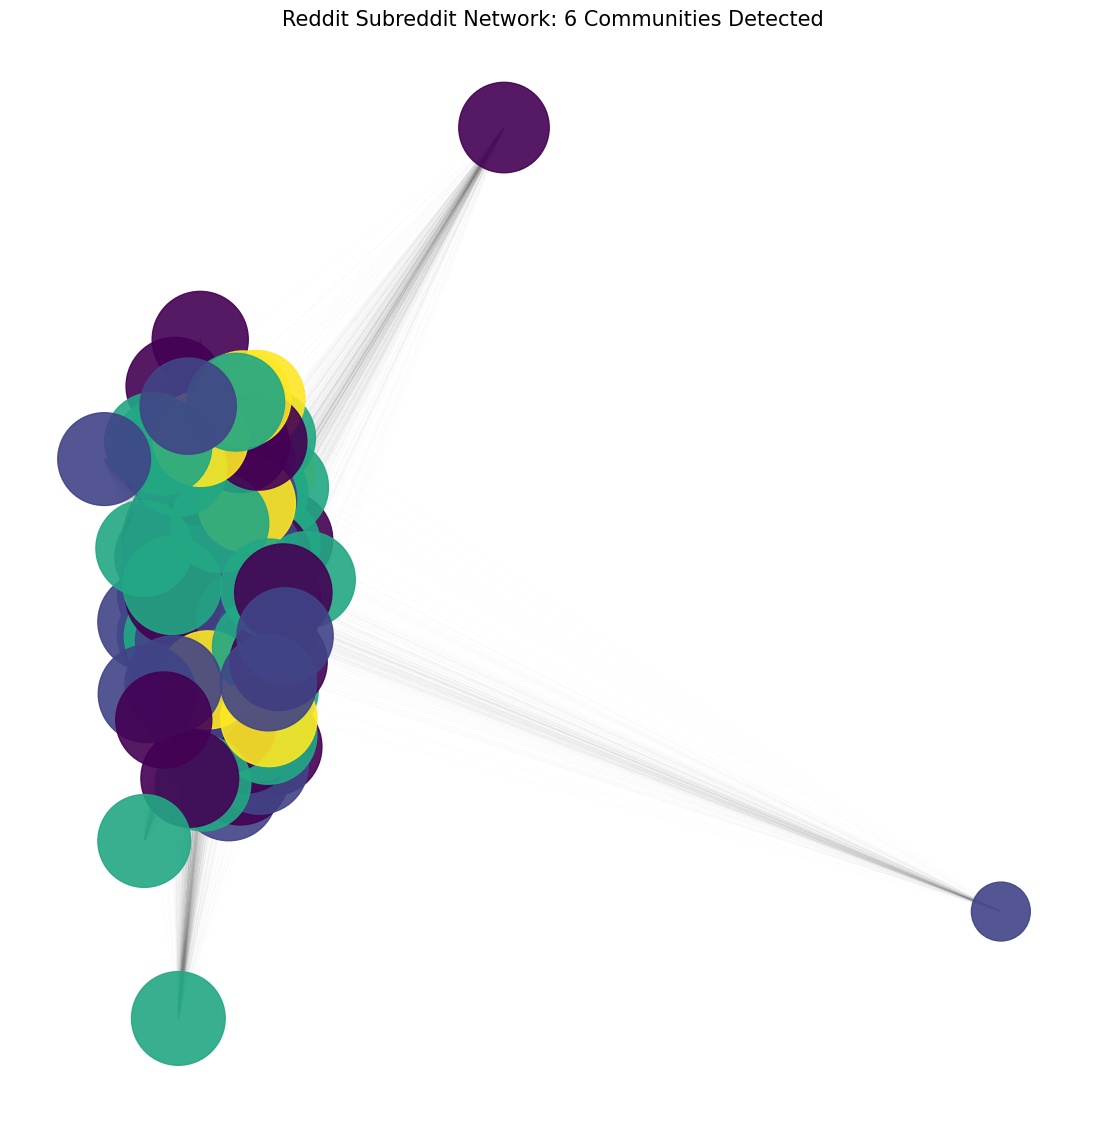

In [122]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Detect Communities (using the Louvain method)
# This returns a list of sets, where each set is a community
communities = nx.community.louvain_communities(reddit_network, seed=42)

# 2. Create a color map: {node: community_index}
node_to_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_to_community[node] = i

# 3. Define colors for each community
# We use a colormap that can handle many distinct colors
cmap = cm.get_cmap('viridis', len(communities))
node_colors = [node_to_community[node] for node in reddit_network.nodes()]

# 4. Calculate Node Sizes based on Degree (Connections)
# This makes 'hubs' bigger and more visible
node_sizes = [d * 10 for _, d in reddit_network.degree()]

# 5. Improved Visualization
plt.figure(figsize=(14, 14))

# Use a higher 'k' value in spring_layout to push nodes further apart
pos = nx.spring_layout(reddit_network, k=0.15, seed=42)

# Draw edges first with high transparency (alpha)
nx.draw_networkx_edges(reddit_network, pos, alpha=0.05, edge_color="gray", width=0.3)

# Draw nodes with community colors
nodes = nx.draw_networkx_nodes(
    reddit_network, 
    pos, 
    node_size=node_sizes, 
    node_color=node_colors, 
    cmap=cmap,
    alpha=0.9
)

plt.title(f"Reddit Subreddit Network: {len(communities)} Communities Detected", fontsize=15)
plt.axis('off')
plt.show()

In [123]:
import json
from networkx.readwrite import json_graph

# 1. Add the community and size data to the node attributes so D3 can see them
for node in reddit_network.nodes():
    reddit_network.nodes[node]['group'] = node_to_community[node]
    reddit_network.nodes[node]['size'] = reddit_network.degree(node)

# 2. Convert to a format D3 understands (node-link format)
data = json_graph.node_link_data(reddit_network)

# 3. Save it
with open('subreddit_data.json', 'w') as f:
    json.dump(data, f)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/networkx/readwrite/json_graph/node_link.py:145: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


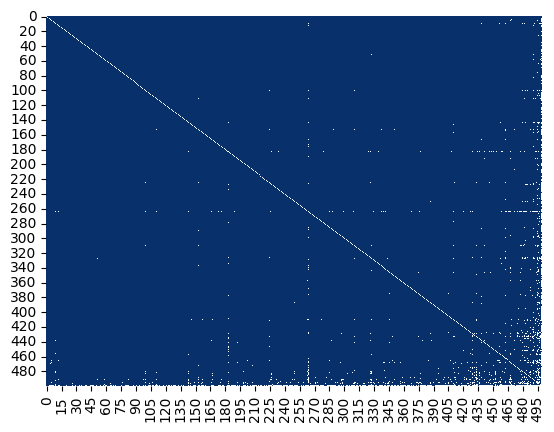

In [125]:
import seaborn as sns
# Get the matrix
adj_matrix = nx.to_numpy_array(reddit_network)
# Sort it by community (this is the key to seeing the structure!)
# [Code to sort by community would go here]
sns.heatmap(adj_matrix, cbar=False, cmap="Blues")
plt.show()

In [126]:
nx.write_gexf(reddit_network, "reddit_for_gephi.gexf")

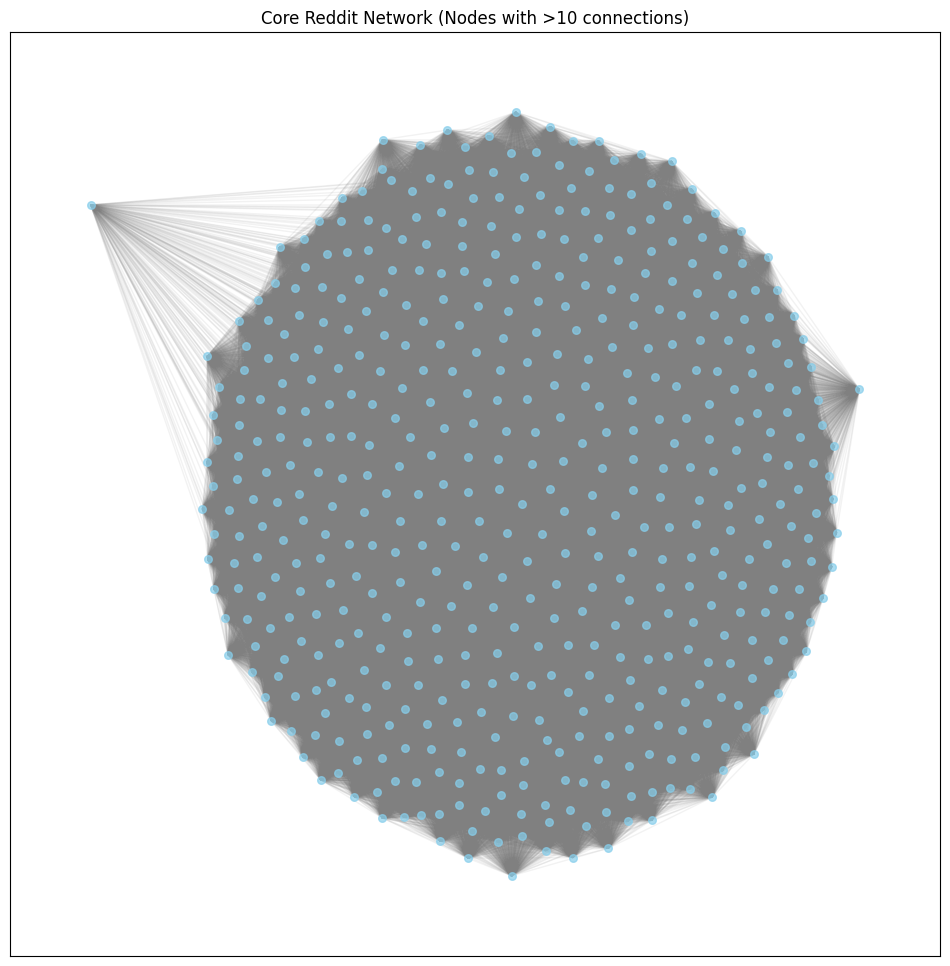

In [127]:
# Create a pruned version of your network
# We only keep the "important" subreddits (degree > threshold)
threshold = 10 
core_nodes = [n for n, d in reddit_network.degree() if d > threshold]
sub_G = reddit_network.subgraph(core_nodes)

plt.figure(figsize=(12, 12))
# Use 'k' to push nodes apart and 'iterations' to make it look cleaner
pos = nx.spring_layout(sub_G, k=0.3, iterations=50)

nx.draw_networkx_nodes(sub_G, pos, node_size=30, node_color="skyblue", alpha=0.7)
nx.draw_networkx_edges(sub_G, pos, alpha=0.1, edge_color="gray")
plt.title(f"Core Reddit Network (Nodes with >{threshold} connections)")
plt.show()